In [136]:
import pandas as pd

from pathlib import Path

import smtplib, ssl

### Load Scores

In [137]:
exercise_path = Path("course_directory/ads_exercise/final_grades")
output_path = Path("total_score")

In [138]:
# set this manually, when the score is not right
max_score = 86.0 - 11.0

In [139]:
scores = pd.read_csv(exercise_path.joinpath("SoSe25/grades_manual.csv"))
scores.head()

,assignment,duedate,timestamp,student_id,last_name,first_name,email,raw_score,late_submission_penalty,score,max_score
0,0-setup,NaN,NaN,moesten,NaN,NaN,NaN,1.0,0.0,1.0,1.0
1,0-setup,NaN,NaN,236de,NaN,NaN,NaN,1.0,0.0,1.0,1.0
2,0-setup,NaN,NaN,Akhil378,NaN,NaN,NaN,1.0,0.0,1.0,1.0
3,0-setup,NaN,NaN,AlagieK,NaN,NaN,NaN,1.0,0.0,1.0,1.0
4,0-setup,NaN,NaN,AnMei2000,NaN,NaN,NaN,1.0,0.0,1.0,1.0


In [140]:
score_long = scores.set_index(["student_id", "assignment"]).sort_index()
score_long

duedate  timestamp  last_name  first_name  \
student_id assignment                                                      
236de      0-setup                 NaN        NaN        NaN         NaN   
           1-python-basics-I       NaN        NaN        NaN         NaN   
           2-python-basics-II      NaN        NaN        NaN         NaN   
           3-control-flow          NaN        NaN        NaN         NaN   
           4-dicts-classes         NaN        NaN        NaN         NaN   
...                                ...        ...        ...         ...   
yz32ityd   4-dicts-classes         NaN        NaN        NaN         NaN   
           5-numpy-scipy           NaN        NaN        NaN         NaN   
           6-pandas                NaN        NaN        NaN         NaN   
           7-statistics            NaN        NaN        NaN         NaN   
           8-visualization         NaN        NaN        NaN         NaN   

                               email  raw_score  late_submission_penalty  \
student_id assignment                                                      
236de      0-setup               NaN        1.0                      0.0   
           1-python-basics-I     NaN        8.0                      0.0   
           2-python-basics-II    NaN       10.0                      0.0   
           3-control-flow        NaN       10.0                      0.0   
           4-dicts-classes       NaN       13.0                      0.0   
...                              ...        ...                      ...   
yz32ityd   4-dicts-classes       NaN       12.5                      0.0   
           5-numpy-scipy         NaN        0.0                      0.0   
           6-pandas              NaN        8.0                      0.0   
           7-statistics          NaN       11.0                      0.0   
           8-visualization       NaN       11.0                      0.0   

                               score  max_score  
student_id assignment                            
236de      0-setup               1.0        1.0  
           1-python-basics-I     8.0        8.0  
           2-python-basics-II   10.0       10.0  
           3-control-flow       10.0       10.0  
           4-dicts-classes      13.0       13.0  
...                              ...        ...  
yz32ityd   4-dicts-classes      12.5       13.0  
           5-numpy-scipy         0.0       10.0  
           6-pandas              8.0       12.0  
           7-statistics         11.0       11.0  
           8-visualization      11.0       11.0  

[1440 rows x 9 columns]

In [141]:
score_long["score"] = score_long["raw_score"]

In [142]:
# generate detailed scores

score_detailed = score_long["score"].unstack("assignment")

score_detailed["total_score"] = score_detailed.sum(axis=1)
score_detailed["percentage"] = score_detailed["total_score"] / max_score  * 100

# cap percentage at 100%
score_detailed["percentage"] = score_detailed["percentage"].clip(upper=100)

# add a column with the bonus points (0.3 when over 90%, 0.6 when over 95%)
score_detailed["bonus"] = 0
score_detailed.loc[score_detailed["percentage"] > 90, "bonus"] = 0.3
score_detailed.loc[score_detailed["percentage"] > 95, "bonus"] = 0.6

/var/folders/3_/6bdchgy93zggkgq8kw8gyssr0000gn/T/ipykernel_88827/3616740669.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.3' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  score_detailed.loc[score_detailed["percentage"] > 90, "bonus"] = 0.3


In [143]:
score_detailed

assignment,0-setup,1-python-basics-I,2-python-basics-II,3-control-flow,4-dicts-classes,5-numpy-scipy,6-pandas,7-statistics,8-visualization,total_score,percentage,bonus
student_id,,,,,,,,,,,,
236de,1.0,8.0,10.0,10.0,13.0,10.0,12.0,11.0,0.0,75.0,100.000000,0.6
Akhil378,1.0,8.0,10.0,10.0,12.5,10.0,12.0,11.0,11.0,85.5,100.000000,0.6
AlagieK,1.0,8.0,10.0,10.0,11.5,0.0,0.0,0.0,0.0,40.5,54.000000,0.0
AnMei2000,1.0,8.0,10.0,10.0,13.0,0.0,12.0,0.0,2.0,56.0,74.666667,0.0
Anjanapmaya,1.0,8.0,0.0,0.0,6.0,0.0,0.0,0.0,11.0,26.0,34.666667,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
vasanth418,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
wasiiik,0.0,8.0,10.0,0.0,13.0,10.0,0.0,0.0,0.0,41.0,54.666667,0.0
yeasin-shampod,1.0,8.0,9.5,0.0,13.0,10.0,9.0,11.0,11.0,72.5,96.666667,0.6


In [144]:
# export to csv
#score_detailed.to_csv(output_path.joinpath("2025_score_detailed.csv"))

In [145]:
sum_points = score_long["score"].unstack("assignment").sum(axis=1)
sum_points

student_id
236de             75.0
Akhil378          85.5
AlagieK           40.5
AnMei2000         56.0
Anjanapmaya       26.0
                  ... 
vasanth418         0.0
wasiiik           41.0
yeasin-shampod    72.5
yy-0715           63.0
yz32ityd          53.5
Length: 160, dtype: float64

In [146]:
#sum_points.to_csv(output_path.joinpath("2025_final.csv"), header=["total_score"])

In [147]:
#max_score = score_long.xs(score_long.index[0][0], level="student_id")["max_score"].sum() # select the first student
#max_score

In [148]:
percentage = (sum_points / max_score) * 100 
percentage[percentage > 100] = 100
percentage = percentage.sort_values(ascending=False)

<Axes: >

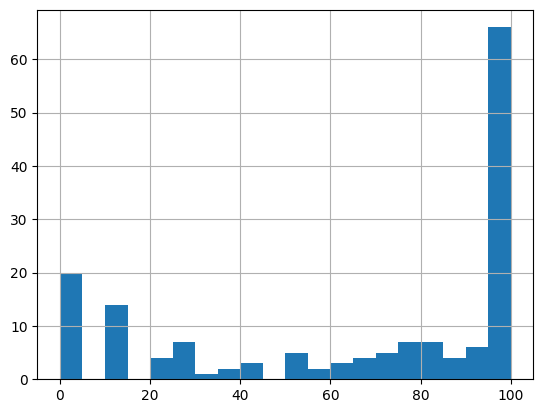

In [149]:
percentage.hist(bins=20)

In [150]:
import time

semester = "SoSe_25"

# export csv
timestr = time.strftime("%Y%m%d-%H%M%S")
percentage.to_csv(output_path.joinpath(semester+"-"+timestr+".csv"))

In [151]:
idm_list = pd.read_csv("course_directory/classroom_roster.csv").loc[:,["identifier", "github_username"]]
idm_list

,identifier,github_username
0,ab84abiq,AlagieK
1,ac00ukok,MinsuSeo-FAU
2,ac13atok,MeDietrich
3,ac41ycar,sohansorker
4,ac41ycar-1,SHAHRIFAT
...,...,...
260,yz59ejus,NaN
261,yz92ybew,NaN
262,ze30qyse,NaN
263,ze61nido,NaN


In [152]:
idm_list.set_index("github_username", inplace=True)
idm_list.index.name = "student_id"

In [153]:
idm_list

,identifier
student_id,
AlagieK,ab84abiq
MinsuSeo-FAU,ac00ukok
MeDietrich,ac13atok
sohansorker,ac41ycar
SHAHRIFAT,ac41ycar-1
...,...
NaN,yz59ejus
NaN,yz92ybew
NaN,ze30qyse


In [154]:
# join percentage and idm_list

total = pd.DataFrame(percentage, columns=["score_percent"]).join(idm_list, how="inner")
total

,score_percent,identifier
student_id,,
236de,100.0,im87ixel
Kshitij741,100.0,so42jawi
TheMightyRaider,100.0,ac98axiw
Dirrrrrk,100.0,ru02cyro
tosiful,100.0,eq35ilyv
...,...,...
Jeevanstephen,0.0,af72agil
TMP1377,0.0,vy63bahe
Frederick-tharun,0.0,yg49ojok


In [155]:
# drop all rows with identifier length > 8 

total.drop(total[total['identifier'].str.len() > 8].index, inplace = True)

In [156]:
total

,score_percent,identifier
student_id,,
236de,100.0,im87ixel
Kshitij741,100.0,so42jawi
TheMightyRaider,100.0,ac98axiw
Dirrrrrk,100.0,ru02cyro
tosiful,100.0,eq35ilyv
...,...,...
Jeevanstephen,0.0,af72agil
TMP1377,0.0,vy63bahe
Frederick-tharun,0.0,yg49ojok


In [157]:
total = total.reset_index().set_index("identifier").drop("student_id", axis=1).sort_index()
total

,score_percent
identifier,
ab84abiq,54.000000
ac00ukok,100.000000
ac13atok,97.333333
ac41ycar,1.333333
ac83ekob,71.333333
...,...
yr06ixyv,12.000000
yr64yqys,93.333333
yv11ovir,77.333333


In [158]:
total.loc["ez55etuw"]

score_percent    99.333333
Name: ez55etuw, dtype: float64

In [159]:
total.to_csv(output_path.joinpath("2025_final.csv"))

In [95]:
mails = pd.read_csv('studon_export/mails/mails2024.csv')
mails = mails[["Login", "E-Mail", "First Name", "Last Name"]]
mails

,Login,E-Mail,First Name,Last Name
0,zy41qyfy,mohammad.al.husseiny@fau.de,Mohammad,Al Husseiny
1,le49xeof,moritz.aschoff@fau.de,Moritz,Aschoff
2,sa01juwe,darren.babu@fau.de,Morris Darren,Babu
3,vi92tyju,mahdieh.saina.baghnavi@fau.de,Sarina,Baghnavi
4,ze30qyse,parisa.bastani@fau.de,Parisa,Bastani
...,...,...,...,...
95,qa23jora,farhan.zahin@fau.de,Farhan,Zahin
96,ed16eteh,zeinab.zarrabi@fau.de,Seyedeh Zeinab,Zarrabi
97,ta49rihe,zhihao.k.zhao@fau.de,Zhihao,Zhao
98,if64azoc,sheng.zhong@fau.de,Sheng,Zhong


In [25]:
# rename columns
mails = mails.rename({"Login":"identifier", "E-Mail":"email", "First Name":"first_name", "Last Name":"last_name"}, axis=1).set_index("identifier")
mails

,email,first_name,last_name
identifier,,,
zy41qyfy,mohammad.al.husseiny@fau.de,Mohammad,Al Husseiny
le49xeof,moritz.aschoff@fau.de,Moritz,Aschoff
sa01juwe,darren.babu@fau.de,Morris Darren,Babu
vi92tyju,mahdieh.saina.baghnavi@fau.de,Sarina,Baghnavi
ze30qyse,parisa.bastani@fau.de,Parisa,Bastani
...,...,...,...
qa23jora,farhan.zahin@fau.de,Farhan,Zahin
ed16eteh,zeinab.zarrabi@fau.de,Seyedeh Zeinab,Zarrabi
ta49rihe,zhihao.k.zhao@fau.de,Zhihao,Zhao


In [26]:
email_result = total.join(mails, how="inner")
email_result

,score_percent,email,first_name,last_name
identifier,,,,
ac13atok,9.0,meike.dietrich@fau.de,Meike,Dietrich
ac28azeg,1.0,utkarsh.singh@fau.de,Utkarsh Ajeet,Singh
ag46abiw,0.0,nour.m.obahji@fau.de,Mohamad,Obahji
as73isud,100.0,mahdi.layeghi@fau.de,Mahdi,Layeghi
at74ynyg,2.5,rachana.kafle@fau.de,Rachana,Kafle
cu40xetu,95.5,zheng.zy.yang@fau.de,Zheng,Yang
cy73sela,41.0,luca.hanke@fau.de,Luca Antonia,Hanke
ec40odyf,35.0,anastasiya.shalamitskaya@fau.de,Anastasiya,Shalamitskaya
ej80ogyg,0.0,andreas.kaerner@t-online.de,Andreas,Kärner


In [28]:
# throw out score percent < 50
email_result = email_result[email_result["score_percent"] >= 50]
email_result

,score_percent,email,first_name,last_name
identifier,,,,
as73isud,100.0,mahdi.layeghi@fau.de,Mahdi,Layeghi
cu40xetu,95.5,zheng.zy.yang@fau.de,Zheng,Yang
en82ymiw,100.0,viktoria.ratnikov@fau.de,Viktoria,Ratnikov
fi46dely,100.0,srinjoy.ghosh@fau.de,Srinjoy,Ghosh
fy56zemu,88.0,jan.viktora@fau.de,Jan,Viktora
hi03vuqi,99.0,michael.gusyev@fau.de,Michael,Gusyev
ig51ozof,100.0,yasaman.moradi.fard@fau.de,Yasaman,Moradi Fard
in72oxep,95.0,malena.p.grimm@fau.de,Malena,Grimm Piquer
ky38hefe,68.0,thilo.stute@fau.de,Thilo,Stute


In [29]:
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText

import time

In [31]:
# write mail
smtp_server = "smtp.gmail.com"
port = 587  # For starttls
sender_email = "dipsylab@gmail.com"
password = "eestjmljnibjgesu"

# Create a secure SSL context
context = ssl.create_default_context()

# Try to log in to server and send email
try:
    server = smtplib.SMTP(smtp_server,port)
    server.ehlo() # Can be omitted
    server.starttls(context=context) # Secure the connection
    server.ehlo() # Can be omitted
    server.login(sender_email, password)
    
    # send mail here
    for identifier, student in email_result[:5].iterrows():
        message = MIMEMultipart()

        message["From"] = sender_email
        message["To"] = student.email
        message["Subject"] = "ADS Exercise Result"

        # Add body to email
        
        message.attach(MIMEText(f"Hi {student.first_name}, \n\n your total score is {round(student.score_percent, 1)} %.  \n\n Best regards, \n ADS Team", "plain"))
        
        message.attach(MIMEText(f"\n\n This message was automatically generated. Please do not reply to this email.", "plain"))

        server.sendmail(sender_email, "luca.abel@fau.de", message.as_string())
        #wait for 1 second

        time.sleep(1)    
except Exception as e:
    # Print any error messages to stdout
    print(e)
finally:
    server.quit() 

(535, b'5.7.8 Username and Password not accepted. For more information, go to\n5.7.8  https://support.google.com/mail/?p=BadCredentials 5b1f17b1804b1-427d2a3c09csm150842535e9.9 - gsmtp')
